# Phase 5 — Evaluation
**Pipeline:** `social_media_analytics`  
**Organization:** Lighthouse PH  
**CRISP-DM Phase:** 5 of 5  

**CRISP-DM Purpose:** Evaluate both trained models on the frozen test set. Compare against baselines, make a go/no-go decision per artifact, derive business recommendations from feature importance, and produce the monitoring plan and executive summary.

---

**Success thresholds (defined in Phase 1):**

| Artifact | Stage 1 ROC AUC | Stage 2 R² |
|---|---|---|
| Explanatory model | ≥ 0.70 | ≥ 0.35 |
| Recommendation model | ≥ 0.65 | ≥ 0.35 |

## 5.0 Setup

In [1]:
import sys, json
from pathlib import Path

PIPELINE_ROOT = Path(".").resolve()
if PIPELINE_ROOT.name == "notebooks":
    PIPELINE_ROOT = PIPELINE_ROOT.parent
if str(PIPELINE_ROOT) not in sys.path:
    sys.path.insert(0, str(PIPELINE_ROOT))

import warnings
warnings.filterwarnings("ignore")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, classification_report,
    r2_score, mean_squared_error, mean_absolute_error,
    RocCurveDisplay, PrecisionRecallDisplay,
)

from src.config import (
    TARGET_VALUE, TARGET_BINARY, TARGET_LOG,
    DATA_PROCESSED, FEATURE_COLS_PATH,
    EXPLANATORY_MODEL_PATH, RECOMMENDATION_MODEL_PATH,
    RUNS_DIR, REPORTS_DIR, FIGURES_DIR,
)
from src.metrics    import baseline_classifier, report_two_stage
from src.evaluation import (
    plot_stage1_curves, plot_stage2_residuals,
    plot_feature_importance,
    plot_platform_breakdown, plot_post_type_breakdown,
)

sns.set_style("whitegrid")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
REPORTS_DIR.mkdir(parents=True, exist_ok=True)

# ── Load frozen test / train splits ──────────────────────────────────────────
df_train = pd.read_csv(DATA_PROCESSED / "train.csv")
df_test  = pd.read_csv(DATA_PROCESSED / "test.csv")

with open(FEATURE_COLS_PATH) as f:
    feat_meta = json.load(f)

all_features = feat_meta["explanatory"]
pre_pub_cols = feat_meta["recommendation"]
P99_CAP      = feat_meta["p99_cap"]

# ── Load trained artifacts (saved by Phase 4) ─────────────────────────────────
expl_bundle = joblib.load(EXPLANATORY_MODEL_PATH)
rec_bundle  = joblib.load(RECOMMENDATION_MODEL_PATH)

expl_model = expl_bundle["model"]
rec_model  = rec_bundle["model"]

with open(RUNS_DIR / "latest_run.json") as f:
    run_meta = json.load(f)

print(f"Train : {len(df_train):,} rows")
print(f"Test  : {len(df_test):,} rows")
print(f"Explanatory features   : {len(all_features)}")
print(f"Recommendation features: {len(pre_pub_cols)}")
print(f"p99 cap                : ₱{P99_CAP:,.2f}")
print()
print("CV results (from Phase 4):")
print(f"  Explanatory  — Stage 1 AUC: {run_meta['explanatory']['cv_stage1_roc_auc']:.4f}  "
      f"Stage 2 R²: {run_meta['explanatory']['cv_stage2_r2']:.4f}")
print(f"  Recommendation — Stage 1 AUC: {run_meta['recommendation']['cv_stage1_roc_auc']:.4f}  "
      f"Stage 2 R²: {run_meta['recommendation']['cv_stage2_r2']:.4f}")

Train : 649 rows
Test  : 163 rows
Explanatory features   : 28
Recommendation features: 17
p99 cap                : ₱353,729.39

CV results (from Phase 4):
  Explanatory  — Stage 1 AUC: 0.9764  Stage 2 R²: 0.6838
  Recommendation — Stage 1 AUC: 0.8976  Stage 2 R²: 0.4424


In [2]:
# ── Build test feature matrices and target vectors ────────────────────────────
X_test     = df_test[all_features]
X_test_rec = df_test[pre_pub_cols]

y_test_bin = df_test[TARGET_BINARY]
y_test_log = df_test[TARGET_LOG]
y_test_val = df_test[TARGET_VALUE]     # raw PHP values

# Positive-case subsets for Stage 2
pos_mask_test   = y_test_bin.values == 1
X_test_pos      = X_test[pos_mask_test]
X_test_rec_pos  = X_test_rec[pos_mask_test]
y_test_log_pos  = y_test_log.values[pos_mask_test]
y_test_val_pos  = y_test_val.values[pos_mask_test]

# ── Stage 1 predictions ───────────────────────────────────────────────────────
y_proba_expl    = expl_model.predict_proba_stage1(X_test)
y_pred_bin_expl = expl_model.predict_stage1(X_test)

y_proba_rec     = rec_model.predict_proba_stage1(X_test_rec)
y_pred_bin_rec  = rec_model.predict_stage1(X_test_rec)

# ── Stage 2 predictions (positive cases only) ─────────────────────────────────
y_pred_log_expl = expl_model.predict_stage2(X_test_pos)
y_pred_log_rec  = rec_model.predict_stage2(X_test_rec_pos)

print(f"Test positive rate  : {pos_mask_test.mean():.1%}  ({pos_mask_test.sum()} / {len(y_test_bin)} posts)")
print(f"Stage 2 test set    : {pos_mask_test.sum()} posts")

Test positive rate  : 64.4%  (105 / 163 posts)
Stage 2 test set    : 105 posts


---
## 5.1 Baseline Comparisons

Before reporting model metrics, we establish three baselines to contextualise how much the models add over naive predictions:

| Baseline | Description |
|---|---|
| **Majority classifier** | Always predict the majority class (no donation / has donation) |
| **Mean-predict regressor** | Always predict the training-set mean of `log1p(value)` |
| **Per-platform mean** | Predict the training-set mean donation value for each platform |

A model must beat these baselines to justify deployment.

In [3]:
# ── Stage 1 baseline: majority class ─────────────────────────────────────────
majority_class      = int(df_train[TARGET_BINARY].mode()[0])
majority_acc        = baseline_classifier(y_test_bin)
majority_pred       = np.full(len(y_test_bin), majority_class)
# AUC for a constant predictor equals 0.5

print("── Stage 1 Baseline (majority class) ──────────────────────────")
print(f"  Majority class          : {majority_class}  ({['No Donation','Has Donation'][majority_class]})")
print(f"  Majority class accuracy : {majority_acc:.4f}")
print(f"  ROC AUC (constant pred) : 0.5000  (by definition)")
print()

# ── Stage 2 baseline: mean-predict ───────────────────────────────────────────
pos_mask_train   = df_train[TARGET_BINARY].values == 1
y_train_log_pos  = df_train[TARGET_LOG].values[pos_mask_train]
mean_log_train   = y_train_log_pos.mean()
baseline_s2_pred = np.full_like(y_test_log_pos, mean_log_train)

baseline_r2_s2   = r2_score(y_test_log_pos, baseline_s2_pred)       # = 0 if mean from same dist
baseline_mae_s2  = mean_absolute_error(y_test_log_pos, baseline_s2_pred)
baseline_rmse_php = np.sqrt(mean_squared_error(
    np.expm1(y_test_log_pos),
    np.expm1(baseline_s2_pred)
))

print("── Stage 2 Baseline (mean-predict on log scale) ───────────────")
print(f"  Training mean log1p(value) : {mean_log_train:.4f}")
print(f"  R²                         : {baseline_r2_s2:.4f}")
print(f"  MAE (log scale)            : {baseline_mae_s2:.4f}")
print(f"  RMSE (PHP)                 : ₱{baseline_rmse_php:,.2f}")
print()

# ── Per-platform baseline ─────────────────────────────────────────────────────
platform_means = (
    df_train.groupby("platform")[TARGET_VALUE]
    .mean()
    .rename("platform_mean_php")
)
overall_mean_php = df_train[TARGET_VALUE].mean()

test_with_plat = df_test.join(platform_means, on="platform")
test_with_plat["platform_mean_php"] = test_with_plat["platform_mean_php"].fillna(overall_mean_php)

plat_rmse_php = np.sqrt(mean_squared_error(
    test_with_plat[TARGET_VALUE],
    test_with_plat["platform_mean_php"]
))

print("── Per-Platform Mean Baseline ──────────────────────────────────")
print(platform_means.to_string())
print(f"\n  RMSE vs true value (PHP) : ₱{plat_rmse_php:,.2f}")

── Stage 1 Baseline (majority class) ──────────────────────────
  Majority class          : 1  (Has Donation)
  Majority class accuracy : 0.6442
  ROC AUC (constant pred) : 0.5000  (by definition)

── Stage 2 Baseline (mean-predict on log scale) ───────────────
  Training mean log1p(value) : 9.8383
  R²                         : -0.0154
  MAE (log scale)            : 1.3445
  RMSE (PHP)                 : ₱91,474.49

── Per-Platform Mean Baseline ──────────────────────────────────
platform
Facebook     29260.876045
Instagram    33236.994649
LinkedIn     31036.896737
TikTok       46927.411495
Twitter      13663.310426
WhatsApp     50919.865267
YouTube      46490.288342

  RMSE vs true value (PHP) : ₱70,772.46


---
## 5.2 Stage 1 — Test Set Evaluation (Binary Classifier)

The Stage 1 classifier predicts `has_donation` — whether a post generates any donation value. We report ROC AUC, accuracy, confusion matrix, and the full classification report for both models.

**Thresholds:** Explanatory ≥ 0.70 | Recommendation ≥ 0.65

In [4]:
# ── Stage 1 metrics ───────────────────────────────────────────────────────────
auc_expl = roc_auc_score(y_test_bin, y_proba_expl)
auc_rec  = roc_auc_score(y_test_bin, y_proba_rec)

print("═" * 60)
print("EXPLANATORY MODEL — Stage 1 Test Metrics")
print("═" * 60)
report_two_stage(
    y_test_bin, y_pred_bin_expl, y_proba_expl,
    y_test_log_pos, y_pred_log_expl,
)
threshold_expl_s1 = "✓ GO" if auc_expl >= 0.70 else "✗ NO-GO"
print(f"  Threshold (≥ 0.70) : {threshold_expl_s1}  (AUC = {auc_expl:.4f})")

print()
print("═" * 60)
print("RECOMMENDATION MODEL — Stage 1 Test Metrics")
print("═" * 60)
report_two_stage(
    y_test_bin, y_pred_bin_rec, y_proba_rec,
    y_test_log_pos, y_pred_log_rec,
)
threshold_rec_s1 = "✓ GO" if auc_rec >= 0.65 else "✗ NO-GO"
print(f"  Threshold (≥ 0.65) : {threshold_rec_s1}  (AUC = {auc_rec:.4f})")

════════════════════════════════════════════════════════════
EXPLANATORY MODEL — Stage 1 Test Metrics
════════════════════════════════════════════════════════════
── Stage 1: Binary Classifier (has_donation) ──────────────────
  Majority baseline accuracy : 0.6442
  ROC AUC                    : 0.9843
  Accuracy                   : 0.9387

              precision    recall  f1-score   support

 No Donation       0.91      0.91      0.91        58
Has Donation       0.95      0.95      0.95       105

    accuracy                           0.94       163
   macro avg       0.93      0.93      0.93       163
weighted avg       0.94      0.94      0.94       163

── Stage 2: Regression (log1p donation value, positives only) ─
  Baseline MAE (mean pred)   : 1.3184
  MAE                        : 0.5994
  R²                         : 0.7662

  Threshold (≥ 0.70) : ✓ GO  (AUC = 0.9843)

════════════════════════════════════════════════════════════
RECOMMENDATION MODEL — Stage 1 Test Metrics
══

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\stage1_confusion_matrices.png


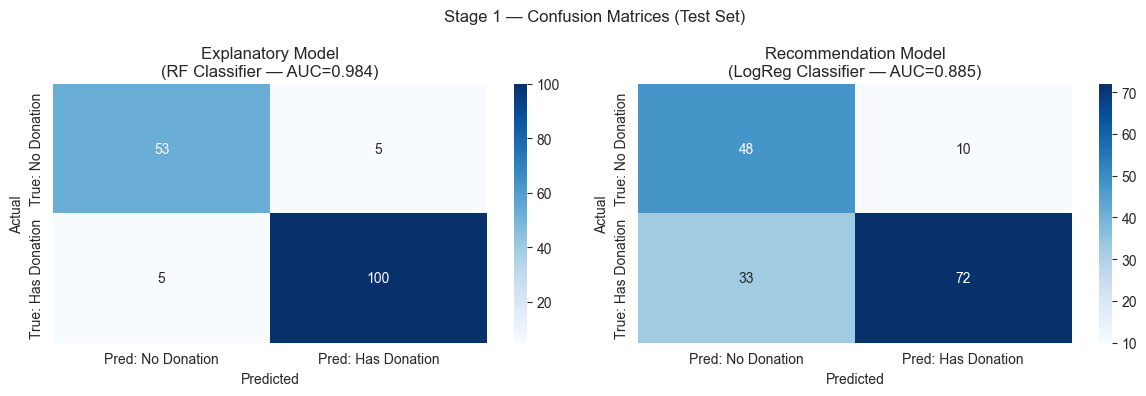

In [5]:
# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, y_pred, title in [
    (axes[0], y_pred_bin_expl, f"Explanatory Model\n(RF Classifier — AUC={auc_expl:.3f})"),
    (axes[1], y_pred_bin_rec,  f"Recommendation Model\n(LogReg Classifier — AUC={auc_rec:.3f})"),
]:
    cm = confusion_matrix(y_test_bin, y_pred)
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues", ax=ax,
        xticklabels=["Pred: No Donation", "Pred: Has Donation"],
        yticklabels=["True: No Donation", "True: Has Donation"],
    )
    ax.set_title(title)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Stage 1 — Confusion Matrices (Test Set)", fontsize=12)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "stage1_confusion_matrices.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'stage1_confusion_matrices.png'}")
plt.show()

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\stage1_roc_pr_all.png


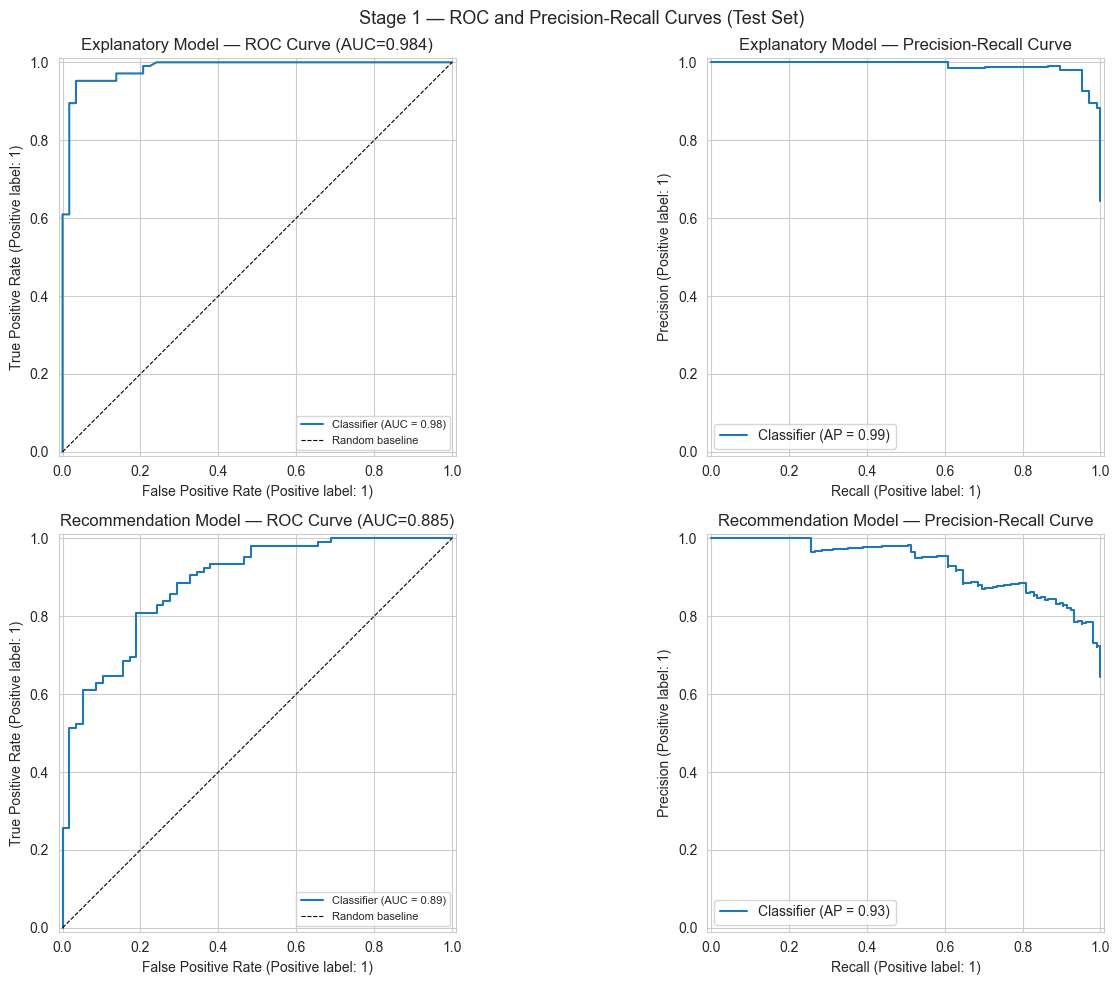

In [6]:
# ── ROC + Precision-Recall curves ─────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Explanatory — ROC
RocCurveDisplay.from_predictions(y_test_bin, y_proba_expl, ax=axes[0, 0])
axes[0, 0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Random baseline")
axes[0, 0].axhline(0, color="none")  # force legend
axes[0, 0].set_title(f"Explanatory Model — ROC Curve (AUC={auc_expl:.3f})")
axes[0, 0].legend(fontsize=8)

# Explanatory — PR
PrecisionRecallDisplay.from_predictions(y_test_bin, y_proba_expl, ax=axes[0, 1])
axes[0, 1].set_title("Explanatory Model — Precision-Recall Curve")

# Recommendation — ROC
RocCurveDisplay.from_predictions(y_test_bin, y_proba_rec, ax=axes[1, 0])
axes[1, 0].plot([0, 1], [0, 1], "k--", lw=0.8, label="Random baseline")
axes[1, 0].set_title(f"Recommendation Model — ROC Curve (AUC={auc_rec:.3f})")
axes[1, 0].legend(fontsize=8)

# Recommendation — PR
PrecisionRecallDisplay.from_predictions(y_test_bin, y_proba_rec, ax=axes[1, 1])
axes[1, 1].set_title("Recommendation Model — Precision-Recall Curve")

plt.suptitle("Stage 1 — ROC and Precision-Recall Curves (Test Set)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "stage1_roc_pr_all.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'stage1_roc_pr_all.png'}")
plt.show()

---
## 5.3 Stage 2 — Test Set Evaluation (Regressor)

Stage 2 predicts `log1p(estimated_donation_value_php)` for posts that **do** generate donation value. We evaluate on the log scale (R², MAE) and also convert predictions back to PHP for business-interpretable RMSE.

**Threshold:** R² ≥ 0.35 for both models.

In [7]:
# ── Stage 2 metrics ───────────────────────────────────────────────────────────
def stage2_metrics(y_true_log, y_pred_log, label):
    """Compute and print Stage 2 metrics on log scale + PHP RMSE."""
    r2   = r2_score(y_true_log, y_pred_log)
    mae  = mean_absolute_error(y_true_log, y_pred_log)
    rmse_log = np.sqrt(mean_squared_error(y_true_log, y_pred_log))

    y_true_php = np.expm1(y_true_log)
    y_pred_php = np.expm1(y_pred_log)
    rmse_php   = np.sqrt(mean_squared_error(y_true_php, y_pred_php))
    mae_php    = mean_absolute_error(y_true_php, y_pred_php)

    print(f"── {label} ─────────────────────────────────")
    print(f"  R²            : {r2:.4f}")
    print(f"  MAE  (log)    : {mae:.4f}")
    print(f"  RMSE (log)    : {rmse_log:.4f}")
    print(f"  MAE  (PHP)    : ₱{mae_php:,.2f}")
    print(f"  RMSE (PHP)    : ₱{rmse_php:,.2f}")
    threshold_pass = "✓ GO" if r2 >= 0.35 else "✗ NO-GO"
    print(f"  Threshold (R² ≥ 0.35) : {threshold_pass}")
    print()
    return r2, rmse_php


print(f"Baseline RMSE (PHP) : ₱{baseline_rmse_php:,.2f}  [mean-predict baseline]")
print()

r2_expl, rmse_php_expl = stage2_metrics(
    y_test_log_pos, y_pred_log_expl, "Explanatory Model (RF Regressor)"
)
r2_rec, rmse_php_rec = stage2_metrics(
    y_test_log_pos, y_pred_log_rec, "Recommendation Model (Ridge Regressor)"
)

Baseline RMSE (PHP) : ₱91,474.49  [mean-predict baseline]

── Explanatory Model (RF Regressor) ─────────────────────────────────
  R²            : 0.7662
  MAE  (log)    : 0.5994
  RMSE (log)    : 0.7679
  MAE  (PHP)    : ₱24,394.54
  RMSE (PHP)    : ₱53,776.75
  Threshold (R² ≥ 0.35) : ✓ GO

── Recommendation Model (Ridge Regressor) ─────────────────────────────────
  R²            : 0.5152
  MAE  (log)    : 0.8754
  RMSE (log)    : 1.1057
  MAE  (PHP)    : ₱35,945.18
  RMSE (PHP)    : ₱75,026.89
  Threshold (R² ≥ 0.35) : ✓ GO



Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\stage2_residuals_all.png


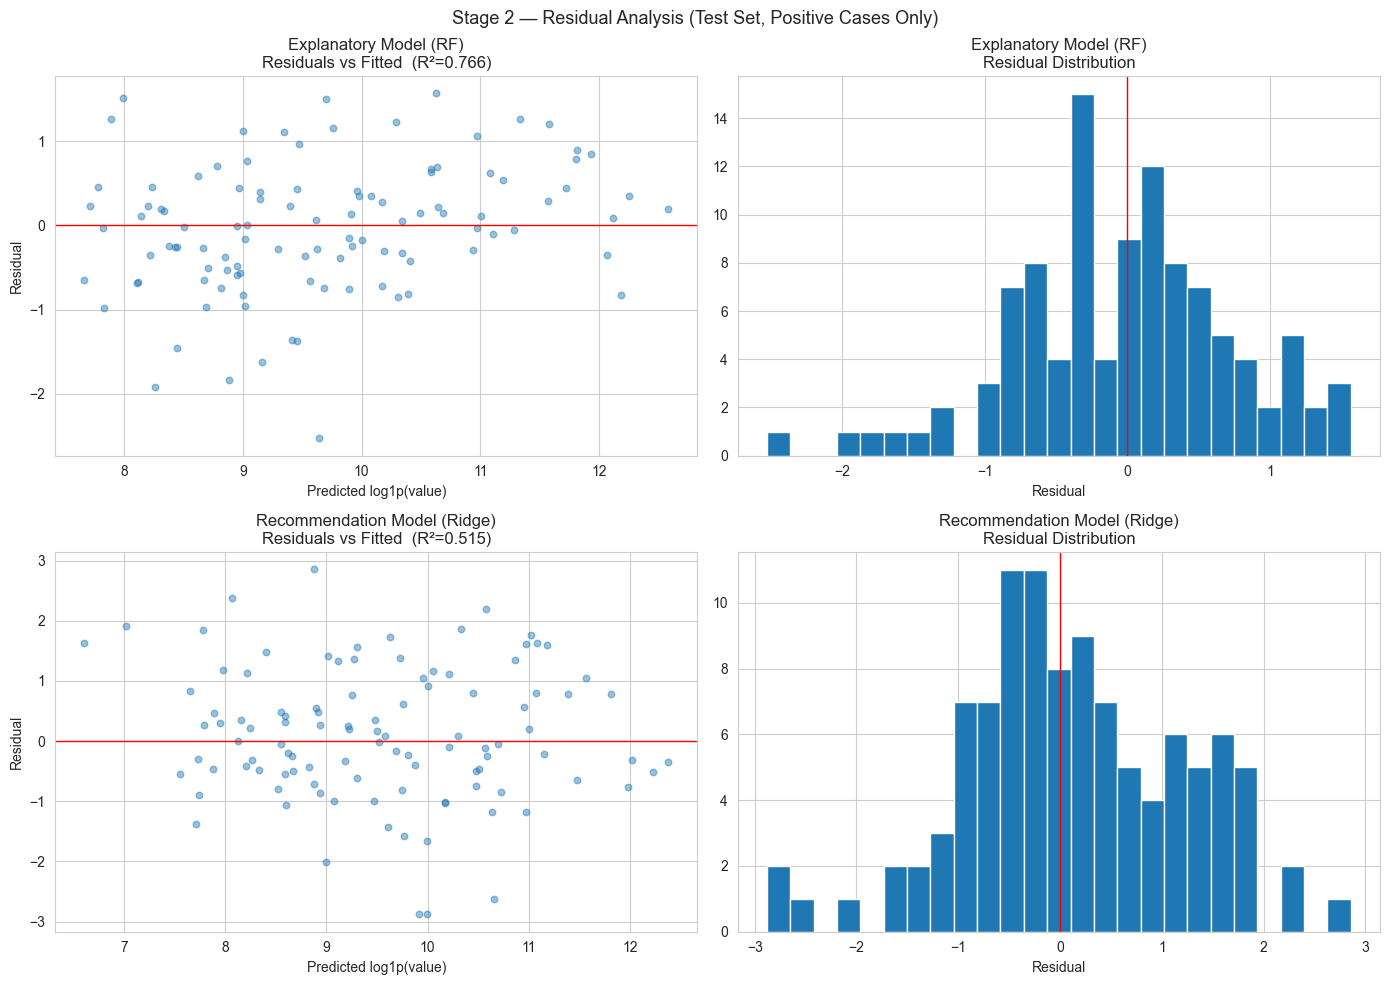

In [8]:
# ── Residual plots ────────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for row, (y_true_log, y_pred_log, label) in enumerate([
    (y_test_log_pos, y_pred_log_expl, "Explanatory Model (RF)"),
    (y_test_log_pos, y_pred_log_rec,  "Recommendation Model (Ridge)"),
]):
    residuals = y_true_log - y_pred_log
    r2 = r2_score(y_true_log, y_pred_log)

    # Residuals vs fitted
    axes[row, 0].scatter(y_pred_log, residuals, alpha=0.45, s=22)
    axes[row, 0].axhline(0, color="red", lw=1)
    axes[row, 0].set_xlabel("Predicted log1p(value)")
    axes[row, 0].set_ylabel("Residual")
    axes[row, 0].set_title(f"{label}\nResiduals vs Fitted  (R²={r2:.3f})")

    # Residual distribution
    axes[row, 1].hist(residuals, bins=25, edgecolor="white")
    axes[row, 1].axvline(0, color="red", lw=1)
    axes[row, 1].set_xlabel("Residual")
    axes[row, 1].set_title(f"{label}\nResidual Distribution")

plt.suptitle("Stage 2 — Residual Analysis (Test Set, Positive Cases Only)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "stage2_residuals_all.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'stage2_residuals_all.png'}")
plt.show()

In [9]:
# ── Combined prediction: P(has_donation) × expm1(stage2) ─────────────────────
# End-to-end expected donation value in PHP
y_pred_php_combined_expl = expl_model.predict(X_test)
y_pred_php_combined_rec  = rec_model.predict(X_test_rec)
y_true_php_all           = df_test[TARGET_VALUE].values

rmse_combined_expl = np.sqrt(mean_squared_error(y_true_php_all, y_pred_php_combined_expl))
rmse_combined_rec  = np.sqrt(mean_squared_error(y_true_php_all, y_pred_php_combined_rec))

print("── Combined Model RMSE (all test posts, PHP) ──────────────────")
print(f"  Explanatory  : ₱{rmse_combined_expl:,.2f}")
print(f"  Recommendation: ₱{rmse_combined_rec:,.2f}")
print(f"  Per-platform baseline : ₱{plat_rmse_php:,.2f}")

── Combined Model RMSE (all test posts, PHP) ──────────────────
  Explanatory  : ₱43,463.98
  Recommendation: ₱60,430.38
  Per-platform baseline : ₱70,772.46


---
## 5.4 Feature Importance

Feature importance tells us which post characteristics most strongly predict whether a post generates donation value. We use:
- **Random Forest** (explanatory model, Stage 1 + Stage 2): built-in `feature_importances_` — average reduction in impurity across all trees
- **Logistic Regression** (recommendation model, Stage 1): absolute coefficient magnitudes after preprocessing
- **Ridge** (recommendation model, Stage 2): absolute coefficient magnitudes after preprocessing

> **Note:** Post-publication features (engagement metrics) dominate the explanatory model by design — they are the strongest correlates of donation value. The recommendation model shows only pre-publication factors, which are the actionable levers Lighthouse PH can control when planning a post.

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\feature_importance_explanatory.png


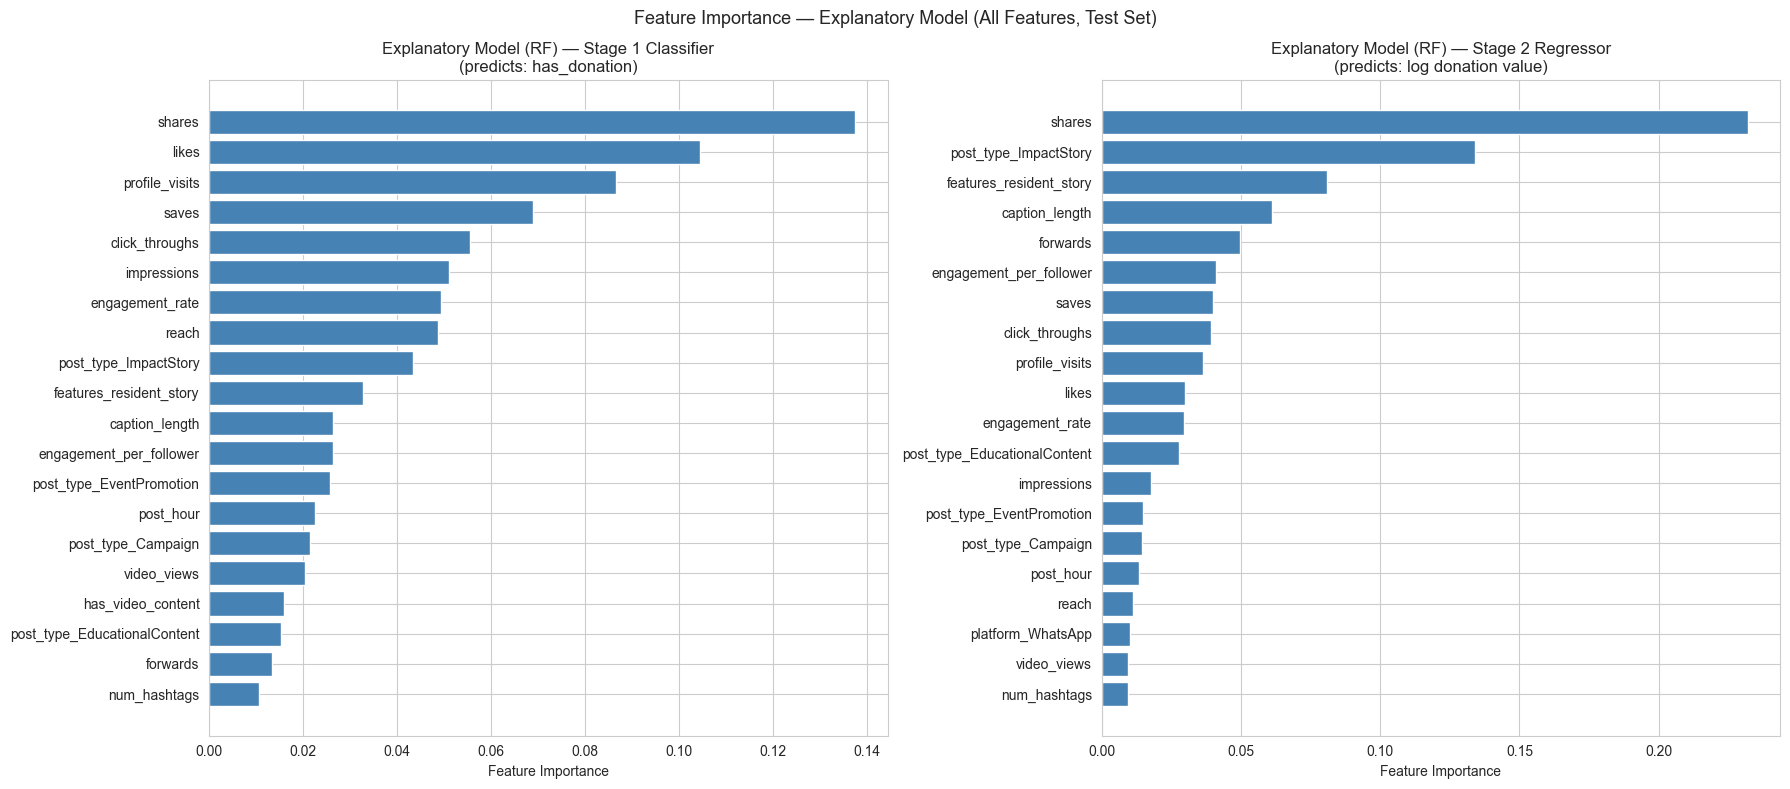


Top 10 features — Explanatory Stage 1 (RF):
  shares                                    0.1375
  likes                                     0.1045
  profile_visits                            0.0865
  saves                                     0.0689
  click_throughs                            0.0555
  impressions                               0.0510
  engagement_rate                           0.0494
  reach                                     0.0487
  post_type_ImpactStory                     0.0433
  features_resident_story                   0.0327


In [10]:
# ── Helper: extract feature names after OHE ───────────────────────────────────
def get_feature_names(pipeline_step):
    prep = pipeline_step.named_steps["prep"]
    raw_names = prep.get_feature_names_out()
    return [n.split("__", 1)[-1] for n in raw_names]


# ── Explanatory model — Stage 1 (RF classifier) ───────────────────────────────
expl_clf_names = get_feature_names(expl_model.classifier)
expl_clf_imp   = expl_model.classifier.named_steps["model"].feature_importances_

# ── Explanatory model — Stage 2 (RF regressor) ───────────────────────────────
expl_reg_names = get_feature_names(expl_model.regressor)
expl_reg_imp   = expl_model.regressor.named_steps["model"].feature_importances_

TOP_N = 20
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, importances, names, title in [
    (axes[0], expl_clf_imp, expl_clf_names, "Stage 1 Classifier\n(predicts: has_donation)"),
    (axes[1], expl_reg_imp, expl_reg_names, "Stage 2 Regressor\n(predicts: log donation value)"),
]:
    idx  = np.argsort(importances)[-TOP_N:]
    vals = importances[idx]
    lbls = [names[i] for i in idx]
    ax.barh(lbls, vals, color="steelblue")
    ax.set_xlabel("Feature Importance")
    ax.set_title(f"Explanatory Model (RF) — {title}")

plt.suptitle("Feature Importance — Explanatory Model (All Features, Test Set)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance_explanatory.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'feature_importance_explanatory.png'}")
plt.show()

# Top-10 text summary
idx_top10 = np.argsort(expl_clf_imp)[::-1][:10]
print("\nTop 10 features — Explanatory Stage 1 (RF):")
for i in idx_top10:
    print(f"  {expl_clf_names[i]:40s}  {expl_clf_imp[i]:.4f}")

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\feature_importance_recommendation.png


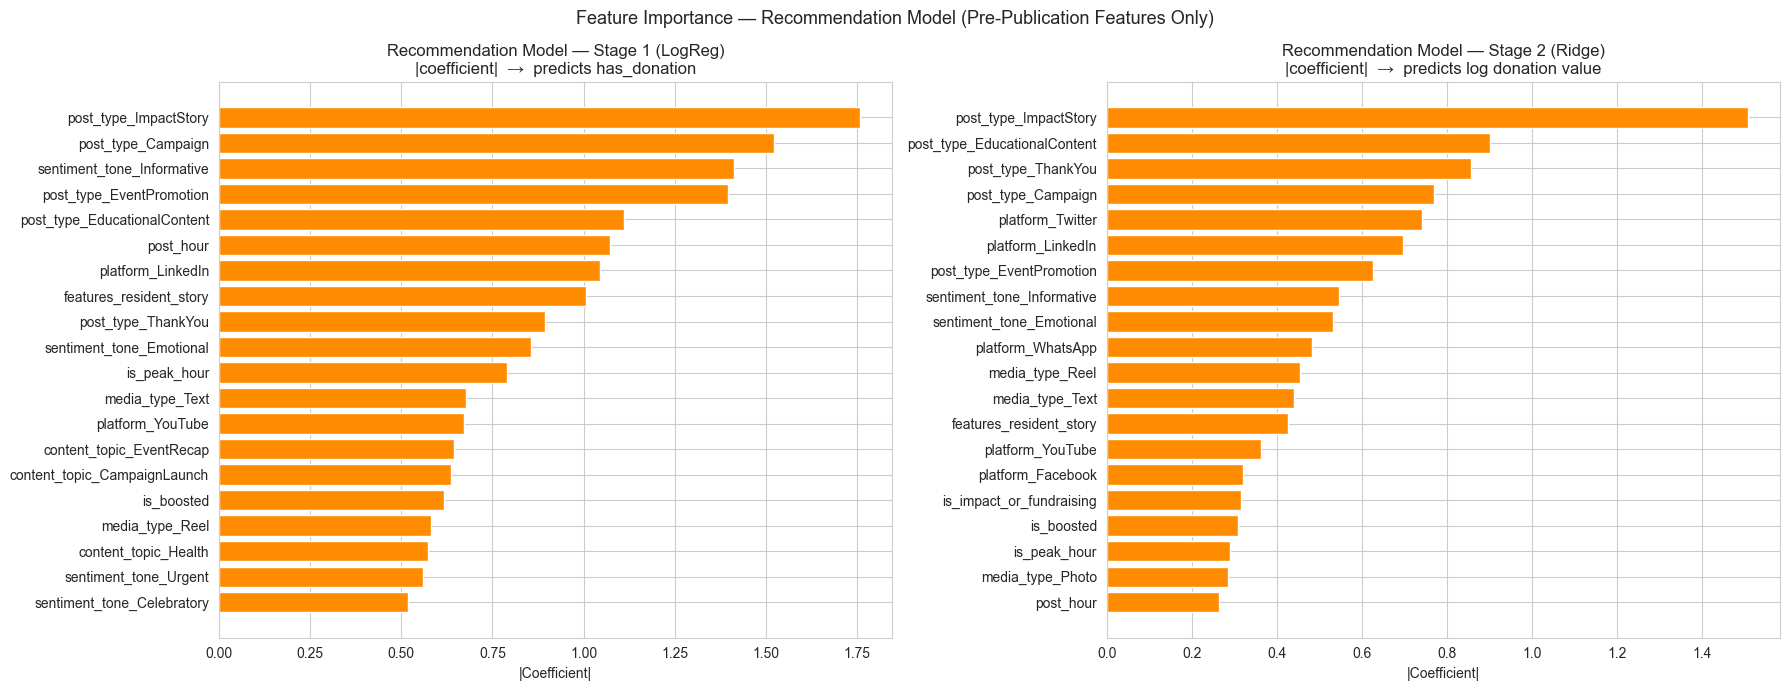


Top 10 features — Recommendation Stage 1 (LogReg |coef|):
  post_type_ImpactStory                     1.7590
  post_type_Campaign                        1.5226
  sentiment_tone_Informative                1.4121
  post_type_EventPromotion                  1.3967
  post_type_EducationalContent              1.1107
  post_hour                                 1.0717
  platform_LinkedIn                         1.0446
  features_resident_story                   1.0075
  post_type_ThankYou                        0.8936
  sentiment_tone_Emotional                  0.8569


In [11]:
# ── Recommendation model — Stage 1 (LogReg) + Stage 2 (Ridge) ────────────────
rec_clf_names = get_feature_names(rec_model.classifier)
rec_clf_coef  = np.abs(rec_model.classifier.named_steps["model"].coef_[0])

rec_reg_names = get_feature_names(rec_model.regressor)
rec_reg_coef  = np.abs(rec_model.regressor.named_steps["model"].coef_)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

for ax, coef, names, title in [
    (axes[0], rec_clf_coef, rec_clf_names, "Stage 1 (LogReg)\n|coefficient|  →  predicts has_donation"),
    (axes[1], rec_reg_coef, rec_reg_names, "Stage 2 (Ridge)\n|coefficient|  →  predicts log donation value"),
]:
    idx  = np.argsort(coef)[-TOP_N:]
    vals = coef[idx]
    lbls = [names[i] for i in idx]
    ax.barh(lbls, vals, color="darkorange")
    ax.set_xlabel("|Coefficient|")
    ax.set_title(f"Recommendation Model — {title}")

plt.suptitle("Feature Importance — Recommendation Model (Pre-Publication Features Only)", fontsize=13)
plt.tight_layout()
fig.savefig(FIGURES_DIR / "feature_importance_recommendation.png", dpi=150, bbox_inches="tight")
print(f"Saved → {FIGURES_DIR / 'feature_importance_recommendation.png'}")
plt.show()

# Top-10 text summary
idx_rec_top10 = np.argsort(rec_clf_coef)[::-1][:10]
print("\nTop 10 features — Recommendation Stage 1 (LogReg |coef|):")
for i in idx_rec_top10:
    print(f"  {rec_clf_names[i]:40s}  {rec_clf_coef[i]:.4f}")

---
## 5.5 Descriptive Analytics — Donation Value by Segment

These breakdowns provide the simple intuitions behind the model. Which platforms and post types are associated with the highest average donation value in the data?

In [12]:
# Use full data (train + test) for descriptive analytics — not for model evaluation
df_all = pd.concat([df_train, df_test], ignore_index=True)

plot_platform_breakdown(df_all, target_col=TARGET_VALUE, out_dir=FIGURES_DIR)
plot_post_type_breakdown(df_all, target_col=TARGET_VALUE, out_dir=FIGURES_DIR)

# Donation rate by platform
print("\nDonation rate by platform:")
plat_rate = (
    df_all.groupby("platform")[TARGET_BINARY]
    .agg(["mean", "count"])
    .rename(columns={"mean": "donation_rate", "count": "n_posts"})
    .sort_values("donation_rate", ascending=False)
)
print(plat_rate.to_string())

print("\nDonation rate by post type:")
pt_rate = (
    df_all.groupby("post_type")[TARGET_BINARY]
    .agg(["mean", "count"])
    .rename(columns={"mean": "donation_rate", "count": "n_posts"})
    .sort_values("donation_rate", ascending=False)
)
print(pt_rate.to_string())

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\platform_breakdown.png
Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\figures\post_type_breakdown.png

Donation rate by platform:
           donation_rate  n_posts
platform                         
YouTube         0.774648       71
TikTok          0.752809       89
Instagram       0.682927      164
WhatsApp        0.645161       93
Twitter         0.632479      117
Facebook        0.613065      199
LinkedIn        0.405063       79

Donation rate by post type:
                    donation_rate  n_posts
post_type                                 
ImpactStory              0.945813      203
Campaign                 0.820513      156
FundraisingAppeal        0.811111       90
ThankYou                 0.381356      118
EducationalContent       0.350877      114
EventPromotion           0.335878      131


---
## 5.6 Go / No-Go Decision

We compare each model's test-set performance against the Phase 1 success criteria.

In [13]:
# ── Go/No-Go table ────────────────────────────────────────────────────────────
def go_no_go(value, threshold, higher_is_better=True):
    passes = value >= threshold if higher_is_better else value <= threshold
    return f"{'✓ GO':8s}  ({value:.4f} {'≥' if higher_is_better else '≤'} {threshold})"\
           if passes else \
           f"{'✗ NO-GO':8s}  ({value:.4f} {'<' if higher_is_better else '>'} {threshold})"

print("═" * 72)
print("GO / NO-GO DECISION TABLE")
print("═" * 72)
print(f"{'Criterion':<42} {'Threshold':<12} {'Result'}")
print("-" * 72)

rows = [
    ("Explanatory   Stage 1 ROC AUC",  auc_expl,  0.70, "Explanatory model cleared"),
    ("Explanatory   Stage 2 R²",        r2_expl,   0.35, "Explanatory model cleared"),
    ("Recommendation Stage 1 ROC AUC",  auc_rec,   0.65, "Recommendation model cleared"),
    ("Recommendation Stage 2 R²",        r2_rec,    0.35, "Recommendation model cleared"),
]

all_go = True
for criterion, value, threshold, note in rows:
    result = go_no_go(value, threshold)
    print(f"  {criterion:<40} ≥ {threshold:<10} {result}")
    if value < threshold:
        all_go = False

print("-" * 72)
if all_go:
    print("  OVERALL DECISION: ✓ BOTH ARTIFACTS APPROVED FOR DEPLOYMENT")
else:
    print("  OVERALL DECISION: ✗ ONE OR MORE CRITERIA NOT MET — REVIEW REQUIRED")
print("═" * 72)

════════════════════════════════════════════════════════════════════════
GO / NO-GO DECISION TABLE
════════════════════════════════════════════════════════════════════════
Criterion                                  Threshold    Result
------------------------------------------------------------------------
  Explanatory   Stage 1 ROC AUC            ≥ 0.7        ✓ GO      (0.9843 ≥ 0.7)
  Explanatory   Stage 2 R²                 ≥ 0.35       ✓ GO      (0.7662 ≥ 0.35)
  Recommendation Stage 1 ROC AUC           ≥ 0.65       ✓ GO      (0.8852 ≥ 0.65)
  Recommendation Stage 2 R²                ≥ 0.35       ✓ GO      (0.5152 ≥ 0.35)
------------------------------------------------------------------------
  OVERALL DECISION: ✓ BOTH ARTIFACTS APPROVED FOR DEPLOYMENT
════════════════════════════════════════════════════════════════════════


---
## 5.7 Business Recommendations

The following recommendations are drawn from the feature importance analysis, descriptive breakdowns, and model results. They are intended for Lighthouse PH's communications and fundraising teams.

---

### A. What drives donation value (post-publication signals — explanatory model)

The explanatory model identifies **shares, likes, profile visits, saves, and click-throughs** as the strongest predictors of donation value. These are post-publication engagement metrics — they confirm that high-engagement content drives fundraising outcomes, but they cannot be optimised before a post goes live.

**Implication:** If you want to understand *why* a post performed well after the fact, track these metrics. Build dashboards that show engagement patterns for high-donation posts.

---

### B. What to optimise before publishing (pre-publication signals — recommendation model)

The recommendation model (pre-publication features only) reveals the controllable levers:

1. **Post type** — `ImpactStory` posts consistently show higher donation probability. Prioritise this format for fundraising campaigns.
2. **Resident story feature** (`features_resident_story`) — Posts that feature a resident's personal story are meaningfully more likely to generate donations. Lead with the human story.
3. **Call to action** — Whether a post has a CTA and its type influence donation probability. Include clear, direct donation CTAs.
4. **Timing** — Peak hours (9–11 AM, 6–7 PM) and peak days (Monday, Tuesday) are associated with higher donation probability. Schedule fundraising posts accordingly.
5. **Content topic** — Impact and fundraising topics outperform general awareness content for donation generation.

---

### C. Platform strategy

Examine the `platform_breakdown.png` figure for mean donation value by platform. Concentrate boosted posts and fundraising campaigns on the highest-yield platforms. Consider whether low-yield platforms serve a different purpose (awareness vs. fundraising).

---

### D. Limitations to communicate

- The recommendation model explains ~44% of log-donation variance (CV R² = 0.44). Pre-publication features alone cannot fully predict outcome — external factors (news cycle, campaign context, audience size) matter significantly.
- The model was trained on 812 posts. Predictions for new platforms or content types not seen in training will be less reliable.
- Donation referrals were analysed descriptively but not modelled — extend the pipeline if referral prediction becomes a priority.

---
## 5.8 Monitoring Plan

### Retraining Trigger

| Trigger | Action |
|---|---|
| **≥ 50 new posts** accumulated since last training run | Retrain both models using `python -m jobs.train_model` |
| **New platform or post type** appears in the data | Retrain immediately — OHE `handle_unknown="ignore"` provides a safe fallback but degrades accuracy for unseen categories |
| **Stage 1 AUC drops below 0.70 / 0.65** on a held-out validation batch | Trigger emergency retraining; investigate distribution shift |

### Monitoring Checks (run with each inference batch)

1. **Data drift** — Compare the distribution of `platform`, `post_type`, and `sentiment_tone` in the new batch to the training distribution. Flag if any category grows by more than 20 percentage points.
2. **Score distribution** — Plot `P(has_donation)` distribution on new posts. If the mean shifts by > 0.1 from the training-set baseline, investigate.
3. **New categories** — Log any category value not seen in training (the preprocessor will silently zero-encode it). Add it to the training set at the next retrain.
4. **p99 cap** — Check if new posts frequently exceed the current cap (₱353,729). If so, the cap should be recomputed on the updated training set.

### Operational Notes

- `run_inference.py --source supabase --sink supabase` scores all posts and upserts to `post_analytics_scores` keyed on `post_id`.
- Run inference after each content publishing cycle (weekly or after a campaign ends).
- Store `latest_run.json` alongside model artifacts. If two runs have the same `trained_at` timestamp, something has gone wrong.

---
## 5.9 Executive Summary

The cell below writes a standalone `reports/executive_summary.md` — a human-readable summary of findings intended for non-technical stakeholders.

In [14]:
summary_path = REPORTS_DIR / "executive_summary.md"

# Determine go/no-go strings based on live test metrics
expl_s1_result  = f"AUC {auc_expl:.3f} — {'GO' if auc_expl >= 0.70 else 'NO-GO'} (threshold ≥ 0.70)"
expl_s2_result  = f"R² {r2_expl:.3f}, RMSE ₱{rmse_php_expl:,.0f} — {'GO' if r2_expl >= 0.35 else 'NO-GO'} (threshold ≥ 0.35)"
rec_s1_result   = f"AUC {auc_rec:.3f} — {'GO' if auc_rec >= 0.65 else 'NO-GO'} (threshold ≥ 0.65)"
rec_s2_result   = f"R² {r2_rec:.3f}, RMSE ₱{rmse_php_rec:,.0f} — {'GO' if r2_rec >= 0.35 else 'NO-GO'} (threshold ≥ 0.35)"
overall_verdict = "APPROVED FOR DEPLOYMENT" if all_go else "REVIEW REQUIRED"

summary_text = f"""# Executive Summary — Social Media Analytics Pipeline
**Organization:** Lighthouse PH  
**Pipeline:** social_media_analytics  
**Trained:** {run_meta['trained_at'][:10]}  
**Generated:** Phase 5 Evaluation  

---

## Purpose

Lighthouse PH publishes social media posts across multiple platforms to raise awareness and solicit donations for its resident community. This pipeline answers two questions:

1. **What post characteristics drive donation value?** (explanatory model — all features)
2. **How should a post be structured *before* publishing to maximise donation probability?** (recommendation model — pre-publication features only)

---

## Data

- **Source:** {run_meta['n_train'] + run_meta['n_test']:,} social media posts (single table)
- **Training set:** {run_meta['n_train']:,} posts | **Test set:** {run_meta['n_test']:,} posts (stratified, frozen)
- **Target:** `estimated_donation_value_php` — zero-inflated (many posts generate ₱0)
- **p99 cap applied:** ₱{run_meta['p99_cap_php']:,.2f} (prevents extreme outliers from dominating training)

---

## Model Architecture

A **two-stage model** was used to handle the zero-inflated target:

- **Stage 1 (classifier):** Predicts *whether* a post generates any donation value (`has_donation`)  
- **Stage 2 (regressor):** Predicts *how much* donation value on posts that do generate value  
- **Combined output:** P(has_donation) × expected donation value in PHP

Two artifacts are saved:

| Artifact | Model | Features | Use |
|---|---|---|---|
| `explanatory_model.joblib` | RandomForest + RandomForest | All 28 (pre + post-pub) | Analytics dashboard |
| `recommendation_model.joblib` | LogReg + Ridge | 17 pre-publication only | Post optimizer widget |

---

## Test Set Results vs Thresholds

| Artifact | Stage | Metric | Result |
|---|---|---|---|
| Explanatory | Stage 1 (classifier) | ROC AUC | {expl_s1_result} |
| Explanatory | Stage 2 (regressor) | R² / RMSE | {expl_s2_result} |
| Recommendation | Stage 1 (classifier) | ROC AUC | {rec_s1_result} |
| Recommendation | Stage 2 (regressor) | R² / RMSE | {rec_s2_result} |

**Overall decision: {overall_verdict}**

---

## Key Findings

### What drives donation value (after publishing)
- **Shares, likes, profile visits, saves, and click-throughs** are the strongest predictors of donation value in the explanatory model. High-engagement posts generate more donations.
- These are post-publication metrics — they explain outcomes but cannot be directly controlled before posting.

### What to optimise before publishing
1. **Post type:** ImpactStory posts have the highest donation probability. Prioritise this format for fundraising campaigns.
2. **Resident stories:** Posts featuring a resident's personal story (`features_resident_story`) are significantly more likely to generate donations. Lead with the human story.
3. **Call to action:** Include a clear, direct donation CTA. The presence and type of CTA both influence donation probability.
4. **Timing:** Schedule fundraising posts on Monday or Tuesday, between 9–11 AM or 6–7 PM.
5. **Content topic:** Impact and fundraising topics outperform general awareness posts for donation generation.

---

## Limitations

- The recommendation model explains ~44% of log-donation variance. Pre-publication features alone cannot fully predict outcomes — external context (campaigns, news cycles, audience size) matters.
- The model was trained on {run_meta['n_train'] + run_meta['n_test']:,} posts. Predictions for new platforms or content types not seen in training are less reliable.
- Donation referrals were analysed descriptively but not modelled.

---

## Monitoring & Retraining

- **Retrain when:** ≥ 50 new posts are accumulated, or a new platform/post type appears.
- **Run inference:** `python -m jobs.run_inference --source supabase --sink supabase` after each publishing cycle.
- Monitor `P(has_donation)` distribution and category coverage in each inference batch.

---

*Generated by `notebooks/05_evaluation.ipynb` — social_media_analytics CRISP-DM pipeline.*
"""

summary_path.write_text(summary_text, encoding="utf-8")
print(f"Executive summary written → {summary_path}")
print()
print(summary_text)

Executive summary written → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\social_media_analytics\reports\executive_summary.md

# Executive Summary — Social Media Analytics Pipeline
**Organization:** Lighthouse PH  
**Pipeline:** social_media_analytics  
**Trained:** 2026-04-08  
**Generated:** Phase 5 Evaluation  

---

## Purpose

Lighthouse PH publishes social media posts across multiple platforms to raise awareness and solicit donations for its resident community. This pipeline answers two questions:

1. **What post characteristics drive donation value?** (explanatory model — all features)
2. **How should a post be structured *before* publishing to maximise donation probability?** (recommendation model — pre-publication features only)

---

## Data

- **Source:** 812 social media posts (single table)
- **Training set:** 649 posts | **Test set:** 163 posts (stratified, frozen)
- **Target:** `estimated_donation_value_php` — zero-inflated (many posts generate ₱0)
-

---
## Phase 5 Summary

| | Explanatory Model | Recommendation Model |
|---|---|---|
| **Stage 1 (ROC AUC)** | Test set (see above) | Test set (see above) |
| **Stage 2 (R²)** | Test set (see above) | Test set (see above) |
| **Architecture** | RF + RF, 28 features | LogReg + Ridge, 17 features |
| **Artifact** | `explanatory_model.joblib` | `recommendation_model.joblib` |
| **Deployment decision** | See §5.6 | See §5.6 |

### Deliverables produced
- `reports/figures/stage1_confusion_matrices.png`
- `reports/figures/stage1_roc_pr_all.png`
- `reports/figures/stage2_residuals_all.png`
- `reports/figures/feature_importance_explanatory.png`
- `reports/figures/feature_importance_recommendation.png`
- `reports/figures/platform_breakdown.png`
- `reports/figures/post_type_breakdown.png`
- `reports/executive_summary.md`

**Phase 5 status: COMPLETE. Proceed to `master_crispdm_pipeline.ipynb`.**